> **LangChain 1.x note:** This notebook has been refreshed to use the current package layout and runnable-oriented patterns where possible. Expect imports such as `langchain_openai`, `langchain_core`, and `langchain_community` instead of older `langchain` monolith imports.

# Chapter 2 — Multimodal Representations and Graph Foundations (v2026)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/IvanReznikov/LangChain4LifeSciencesHealthcare)

**Companion notebook to _LangChain for Life Sciences and Healthcare_.** This notebook builds working, small-scale examples for aligning text, molecules, images, and knowledge graphs. It deliberately separates: (1) representation learning, (2) retrieval, (3) graph reasoning, and (4) evidence/provenance. The examples use a compact synthetic research dataset so they run on CPU; optional cells identify where to substitute production encoders and curated sources.

## Learning objectives

By the end, you should be able to create modality-specific representations, inspect cross-modal similarity, build an evidence-bearing heterogeneous graph, perform transparent neighborhood retrieval, and evaluate without entity, similarity, or temporal leakage.

This notebook introduces multimodal and graph foundations for life-science workflows. It connects structured graph reasoning, molecular representations, and multimodal learning so the later LangChain examples have a clear conceptual base.

> **LangChain 1.x note:** This notebook has been refreshed to use the current package layout and runnable-oriented patterns where possible. Expect imports such as `langchain_openai`, `langchain_core`, and `langchain_community` instead of older `langchain` monolith imports.

## Environment and reproducibility

Run the core installation once. RDKit is optional but enables molecular depictions and fingerprints. The notebook is designed to work without API keys or a GPU.

<details>
<summary>Optional setup and installation</summary>

Use this only when you are preparing a fresh environment. This notebook needs only the scientific-Python / graph stack — **no LLM API keys and no hosted LangChain model calls**.

```bash
%pip install -U numpy pandas matplotlib seaborn networkx scipy
```

(The `langchain` 1.x packages are introduced from Chapter 3 onward and are not required to run this chapter's cells.)
</details>

In [ ]:
#@title Installing dependencies { display-mode: "form" }
!pip install -q rdkit

!pip freeze rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 33.8 MB/s eta 0:00:00


<details>
<summary>Optional setup and installation</summary>

This notebook uses only scientific-Python and graph/plotting libraries (numpy, pandas, matplotlib, seaborn, networkx, scipy) plus the LangChain 1.x split for later chapters — **no LLM API keys are required**. See the single setup note near the top of the notebook; nothing extra is installed here.
</details>

In [ ]:
# %pip install -q numpy pandas matplotlib seaborn plotly networkx scikit-learn
# Optional chemistry support (recommended in Colab):
# %pip install -q rdkit-pypi
import json, random, platform, sys
from dataclasses import dataclass, asdict
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, networkx as nx
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
SEED=42; random.seed(SEED); rng=np.random.default_rng(SEED); np.random.seed(SEED)
print({'python':sys.version.split()[0], 'platform':platform.platform(), 'seed':SEED})

{'python': '3.12.13', 'platform': 'Linux-6.6.122+-x86_64-with-glibc2.35', 'seed': 42}


## A small multimodal research corpus

Each row represents a compound-centered evidence item. In real projects, replace this table with versioned source records and retain identifiers, dates, extraction method, and confidence. Do not infer causal claims from embedding proximity.

In [ ]:
records=pd.DataFrame([
 ['CHEBI:15365','aspirin','CC(=O)Oc1ccccc1C(=O)O','PTGS1','pain','Aspirin acetylates cyclooxygenase and is used for pain and inflammation.',2019,'curated',0.95],
 ['CHEBI:5855','ibuprofen','CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O','PTGS2','pain','Ibuprofen is a nonsteroidal anti-inflammatory drug that inhibits cyclooxygenase.',2020,'curated',0.94],
 ['CHEBI:46195','paracetamol','CC(=O)Nc1ccc(O)cc1','PTGS2','pain','Paracetamol is an analgesic with context-dependent cyclooxygenase activity.',2021,'literature',0.78],
 ['CHEBI:15377','water','O','AQP1','edema','Aquaporin channels facilitate water transport across membranes.',2018,'curated',0.97],
 ['CHEBI:6801','caffeine','Cn1cnc2n(C)c(=O)n(C)c(=O)c12','ADORA2A','fatigue','Caffeine antagonizes adenosine receptors and can increase alertness.',2022,'literature',0.82],
],columns=['compound_id','compound','smiles','protein','phenotype','text','year','source','confidence'])
records

,compound_id,compound,smiles,protein,phenotype,text,year,source,confidence
0,CHEBI:15365,aspirin,CC(=O)Oc1ccccc1C(=O)O,PTGS1,pain,Aspirin acetylates cyclooxygenase and is used ...,2019,curated,0.95
1,CHEBI:5855,ibuprofen,CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O,PTGS2,pain,Ibuprofen is a nonsteroidal anti-inflammatory ...,2020,curated,0.94
2,CHEBI:46195,paracetamol,CC(=O)Nc1ccc(O)cc1,PTGS2,pain,Paracetamol is an analgesic with context-depen...,2021,literature,0.78
3,CHEBI:15377,water,O,AQP1,edema,Aquaporin channels facilitate water transport ...,2018,curated,0.97
4,CHEBI:6801,caffeine,Cn1cnc2n(C)c(=O)n(C)c(=O)c12,ADORA2A,fatigue,Caffeine antagonizes adenosine receptors and c...,2022,literature,0.82


## Text representations and text retrieval

TF-IDF is intentionally used as an inspectable baseline. Replace it with a biomedical embedding model only after evaluating the same split, preprocessing policy, and retrieval metrics. A retrieval result is evidence discovery, not validation.

In [ ]:
vectorizer=TfidfVectorizer(stop_words='english',ngram_range=(1,2))
text_vectors=normalize(vectorizer.fit_transform(records.text))
query='nonsteroidal anti-inflammatory treatment for pain'
qv=normalize(vectorizer.transform([query])); scores=cosine_similarity(qv,text_vectors).ravel()
text_results=records[['compound','text','source','confidence']].copy(); text_results['text_similarity']=scores
text_results.sort_values('text_similarity',ascending=False)

,compound,text,source,confidence,text_similarity
1,ibuprofen,Ibuprofen is a nonsteroidal anti-inflammatory ...,curated,0.94,0.578543
0,aspirin,Aspirin acetylates cyclooxygenase and is used ...,curated,0.95,0.126298
2,paracetamol,Paracetamol is an analgesic with context-depen...,literature,0.78,0.000000
3,water,Aquaporin channels facilitate water transport ...,curated,0.97,0.000000
4,caffeine,Caffeine antagonizes adenosine receptors and c...,literature,0.82,0.000000


### From graphs to multimodal features

Below we combine the molecular/graph representations from earlier cells with a synthetic assay-image modality, showing how heterogeneous signals can be joined on a shared compound identifier before being fed to a model.

In [ ]:
def precision_at_k(ranked, relevant, k):
  return sum(x in relevant for x in ranked[:k])/k

def reciprocal_rank(ranked,relevant):
    return next((1/(i+1) for i,x in enumerate(ranked) if x in relevant),0.0)

ranked=records.iloc[np.argsort(-scores)].compound.tolist()
print({'ranked_compounds':ranked,'P@2':precision_at_k(ranked,{'ibuprofen','aspirin'},2),'MRR':reciprocal_rank(ranked,{'ibuprofen','aspirin'})})

{'ranked_compounds': ['ibuprofen', 'aspirin', 'paracetamol', 'water', 'caffeine'], 'P@2': 1.0, 'MRR': 1.0}


## Molecular representation: chemistry-aware baseline

SMILES are serializations, not molecules. The cell computes Morgan fingerprints when RDKit is installed; otherwise it uses a character n-gram fallback solely to keep the pedagogical notebook runnable. Fingerprint similarity and text similarity answer different questions and should not be conflated.

In [ ]:
try:
    from rdkit import Chem, DataStructs
    from rdkit.Chem import AllChem, Draw, Descriptors
    HAVE_RDKIT=True
except ImportError: HAVE_RDKIT=False
print('RDKit available:',HAVE_RDKIT)

def molecular_vectors(smiles):
    if HAVE_RDKIT:
        fps=[AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(s),radius=2,nBits=1024) for s in smiles]
        arr=np.zeros((len(fps),1024),dtype=np.float32)
        for i,fp in enumerate(fps): DataStructs.ConvertToNumpyArray(fp,arr[i])
        return arr
    return normalize(TfidfVectorizer(analyzer='char',ngram_range=(2,4)).fit_transform(smiles)).toarray()
mol_vectors=molecular_vectors(records.smiles)
mol_sim=cosine_similarity(mol_vectors)
pd.DataFrame(mol_sim,index=records.compound,columns=records.compound).round(2)

RDKit available: True


[20:56:53] DEPRECATION WARNING: please use MorganGenerator
[20:56:53] DEPRECATION WARNING: please use MorganGenerator
[20:56:53] DEPRECATION WARNING: please use MorganGenerator
[20:56:53] DEPRECATION WARNING: please use MorganGenerator
[20:56:53] DEPRECATION WARNING: please use MorganGenerator


compound,aspirin,ibuprofen,paracetamol,water,caffeine
compound,,,,,
aspirin,1.00,0.33,0.37,0.0,0.17
ibuprofen,0.33,1.00,0.32,0.0,0.20
paracetamol,0.37,0.32,1.00,0.0,0.19
water,0.00,0.00,0.00,1.0,0.00
caffeine,0.17,0.20,0.19,0.0,1.00


This cell works with **embeddings**, which map inputs into a continuous vector space. Nearby vectors indicate semantic or structural similarity, so this representation becomes useful for retrieval, clustering, and nearest-neighbor analysis.

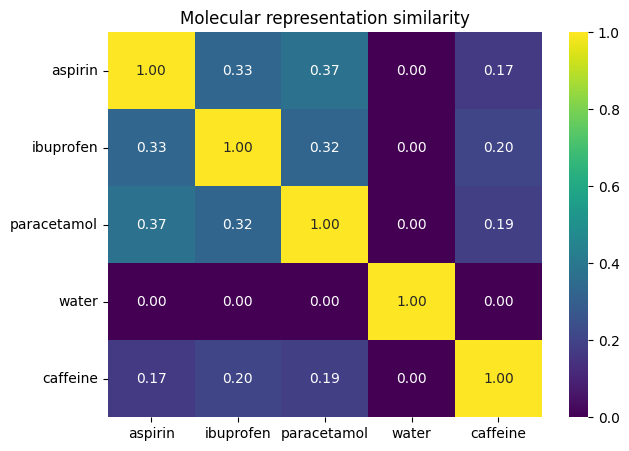

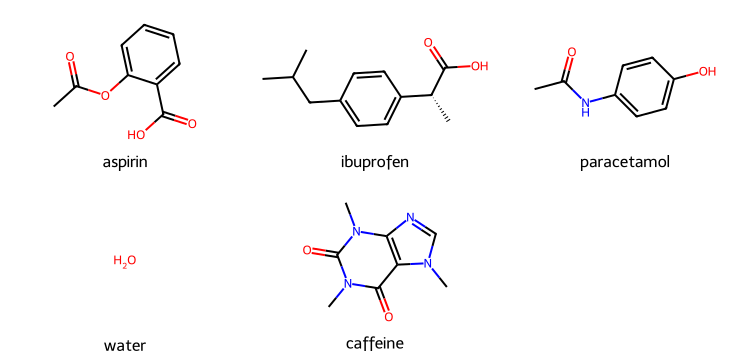

In [ ]:
fig,ax=plt.subplots(figsize=(7,5)); sns.heatmap(mol_sim,xticklabels=records.compound,yticklabels=records.compound,cmap='viridis',vmin=0,vmax=1,annot=True,fmt='.2f',ax=ax)
ax.set_title('Molecular representation similarity'); plt.show()
if HAVE_RDKIT:
    display(Draw.MolsToGridImage([Chem.MolFromSmiles(s) for s in records.smiles],legends=records.compound.tolist(),molsPerRow=3,subImgSize=(250,180)))

## Cross-modal alignment diagnostic

We project independently built text and molecular vectors into a common low-dimensional display. This is a **diagnostic**, not trained multimodal alignment: coordinates are not evidence that a compound description and a molecular graph encode the same biology. Production alignment needs paired supervision and held-out evaluation.

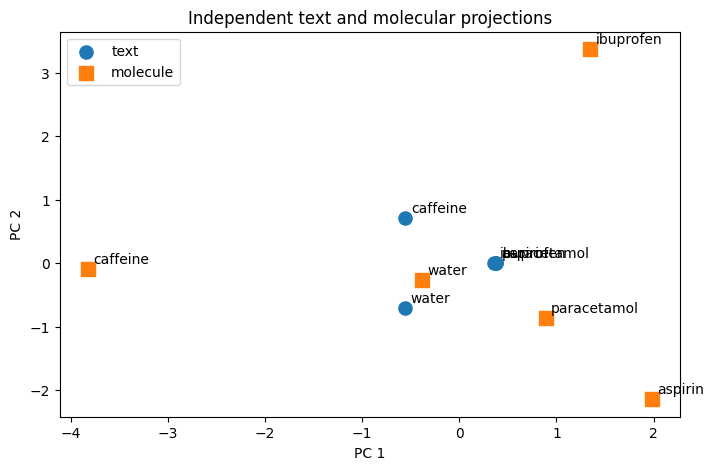

In [ ]:
def to_2d(x):
    x=np.asarray(x.todense() if hasattr(x,'todense') else x)
    return PCA(n_components=2,random_state=SEED).fit_transform(x)
txy=to_2d(text_vectors.toarray())
mxy=to_2d(mol_vectors)
fig,ax=plt.subplots(figsize=(8,5)); ax.scatter(txy[:,0],txy[:,1],s=90,label='text')
ax.scatter(mxy[:,0],mxy[:,1],s=90,marker='s',label='molecule')
for i,n in enumerate(records.compound):
  ax.annotate(n,(txy[i,0],txy[i,1]),xytext=(4,4),textcoords='offset points')
  ax.annotate(n,(mxy[i,0],mxy[i,1]),xytext=(4,4),textcoords='offset points')
ax.set_title('Independent text and molecular projections'); ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2'); ax.legend(); plt.show()

## Image representations: feature extraction before foundation models

Microscopy and pathology workflows require protocol-aware image quality control before semantic embedding. The synthetic images below show a reproducible feature baseline (intensity, spread, gradients), plus a visual montage. Swap the feature extractor for a domain-validated image encoder only after maintaining the same patient/specimen-level split.

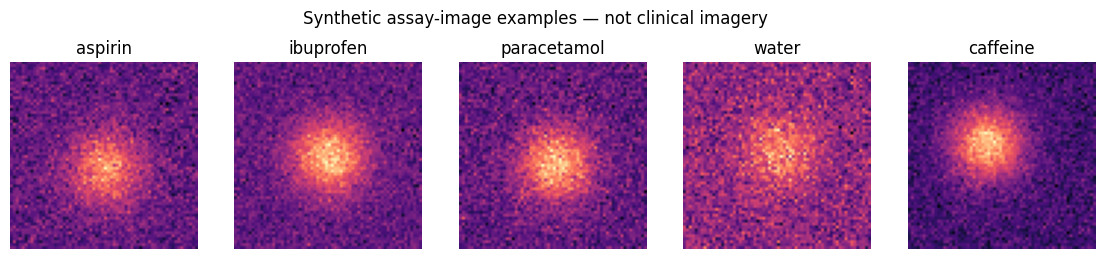

,compound,mean_intensity,intensity_sd,mean_gradient
0,aspirin,0.082803,0.191242,0.340258
1,ibuprofen,0.122160,0.249364,0.364391
2,paracetamol,0.094214,0.211000,0.352268
3,water,0.049498,0.148199,0.341217
4,caffeine,0.153699,0.284862,0.379088


In [ ]:
from scipy.ndimage import sobel  # gaussian_filter was imported earlier but is unused; only sobel is needed
images=[]; image_meta=[]
for compound,scale in zip(records.compound,[.7,1.0,.8,.4,1.2]):
    base=rng.normal(0,.12,(64,64)); y,x=np.mgrid[-1:1:64j,-1:1:64j]
    img=base+scale*np.exp(-((x-rng.uniform(-.2,.2))**2+(y-rng.uniform(-.2,.2))**2)/.16)
    images.append(img); image_meta.append([compound,img.mean(),img.std(),np.abs(sobel(img)).mean()])
image_features=pd.DataFrame(image_meta,columns=['compound','mean_intensity','intensity_sd','mean_gradient'])
fig,axs=plt.subplots(1,len(images),figsize=(14,3))
for ax,img,name in zip(axs,images,records.compound): ax.imshow(img,cmap='magma');ax.set_title(name);ax.axis('off')
plt.suptitle('Synthetic assay-image examples — not clinical imagery');plt.show(); image_features

## Evidence-bearing heterogeneous graph

The graph stores entity type, edge type, source, date, confidence, and whether an edge is demonstrative. This prevents a graph visualization from becoming a black box: every edge remains inspectable.

In [ ]:
G=nx.MultiDiGraph()
for _,r in records.iterrows():
    G.add_node(r.compound_id,label=r.compound,kind='compound',smiles=r.smiles)
    G.add_node(r.protein,label=r.protein,kind='protein')
    G.add_node(r.phenotype,label=r.phenotype,kind='phenotype')
    attrs=dict(source=r.source,year=int(r.year),confidence=float(r.confidence),evidence=r.text,demo=True)
    G.add_edge(r.compound_id,r.protein,relation='targets_or_modulates',**attrs)
    G.add_edge(r.compound_id,r.phenotype,relation='associated_with',**attrs)
print('nodes:',G.number_of_nodes(),'edges:',G.number_of_edges())
pd.DataFrame([{**{'subject':G.nodes[u]['label'],'object':G.nodes[v]['label']},**d} for u,v,d in G.edges(data=True)])[['subject','relation','object','source','year','confidence','demo']]

nodes: 12 edges: 10


,subject,relation,object,source,year,confidence,demo
0,aspirin,targets_or_modulates,PTGS1,curated,2019,0.95,True
1,aspirin,associated_with,pain,curated,2019,0.95,True
2,ibuprofen,targets_or_modulates,PTGS2,curated,2020,0.94,True
3,ibuprofen,associated_with,pain,curated,2020,0.94,True
4,paracetamol,targets_or_modulates,PTGS2,literature,2021,0.78,True
5,paracetamol,associated_with,pain,literature,2021,0.78,True
6,water,targets_or_modulates,AQP1,curated,2018,0.97,True
7,water,associated_with,edema,curated,2018,0.97,True
8,caffeine,targets_or_modulates,ADORA2A,literature,2022,0.82,True
9,caffeine,associated_with,fatigue,literature,2022,0.82,True


This cell emphasizes a **graph-based representation**. Graphs are helpful when relationships matter as much as the entities themselves, which is common in molecular structure, interaction networks, and knowledge graph workflows.

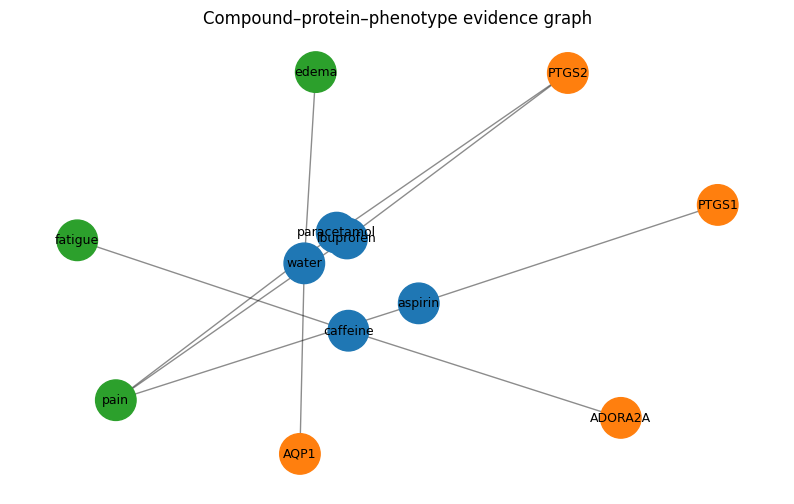

In [ ]:
colors={'compound':'#1f77b4','protein':'#ff7f0e','phenotype':'#2ca02c'}
pos=nx.spring_layout(G,seed=SEED); plt.figure(figsize=(10,6))
nx.draw_networkx_nodes(G,pos,node_color=[colors[G.nodes[n]['kind']] for n in G.nodes],node_size=850)
nx.draw_networkx_edges(G,pos,alpha=.45,arrows=True);nx.draw_networkx_labels(G,pos,labels={n:G.nodes[n]['label'] for n in G.nodes},font_size=9)
plt.title('Compound–protein–phenotype evidence graph');plt.axis('off');plt.show()

## Transparent graph retrieval and provenance

This function returns paths only when edges meet the specified temporal and confidence policy. The output includes the underlying evidence text; graph paths must never be shown without their provenance.

In [ ]:
def evidence_paths(graph,compound_label,min_confidence=.8,available_through=2021):
    start=next(n for n,d in graph.nodes(data=True) if d.get('label')==compound_label)
    rows=[]
    for _,v,k,d in graph.out_edges(start,keys=True,data=True):
        if d['confidence']>=min_confidence and d['year']<=available_through:
            rows.append({'compound':compound_label,'relation':d['relation'],'object':graph.nodes[v]['label'],'year':d['year'],'confidence':d['confidence'],'source':d['source'],'evidence':d['evidence']})
    return pd.DataFrame(rows)
evidence_paths(G,'ibuprofen',.8,2021)

,compound,relation,object,year,confidence,source,evidence
0,ibuprofen,targets_or_modulates,PTGS2,2020,0.94,curated,Ibuprofen is a nonsteroidal anti-inflammatory ...
1,ibuprofen,associated_with,pain,2020,0.94,curated,Ibuprofen is a nonsteroidal anti-inflammatory ...


## Evaluation: leakage-aware link prediction

A random edge split is often invalid in life science because the same compound, near-duplicate molecule, paper family, or later evidence can appear in both train and test. The split below uses time, and the audit explicitly reports whether test compounds are already present in train. In production, also use scaffold, homolog, document-family, and patient-level splits where relevant.

In [ ]:
cutoff=2020
edges=pd.DataFrame([{ 'u':u,'v':v,**d} for u,v,d in G.edges(data=True)])
train=edges.query('year <= @cutoff').copy(); test=edges.query('year > @cutoff').copy()
print({'train_edges':len(train),'test_edges':len(test),'test_subject_seen_in_train':set(test.u)&set(train.u),'cutoff_year':cutoff})
# Simple relation-frequency baseline; intentionally transparent and weak.
prior=train.relation.value_counts(normalize=True).rename('train_relation_prior')
test.join(prior,on='relation')[['relation','year','confidence','train_relation_prior']]

{'train_edges': 6, 'test_edges': 4, 'test_subject_seen_in_train': set(), 'cutoff_year': 2020}


,relation,year,confidence,train_relation_prior
4,targets_or_modulates,2021,0.78,0.5
5,associated_with,2021,0.78,0.5
8,targets_or_modulates,2022,0.82,0.5
9,associated_with,2022,0.82,0.5


## Optional production encoders

Use these only with a pinned model revision, license review, document/image preprocessing log, and an evaluation set that reflects the eventual research task.

```python
# Text: sentence-transformers / PubMedBERT-style encoder
# Image: a pathology or microscopy-validated encoder
# Molecules: GNN or molecular-transformer encoder
# Graph: PyTorch Geometric / DGL heterogeneous graph model
# Keep baseline fingerprint + lexical retrieval in every experiment.
```

## Exercises

1. Add a protein sequence modality and assess whether it improves a predefined compound–target retrieval task.
2. Replace synthetic images with a redistributable, non-clinical assay dataset and add protocol/batch metadata.
3. Implement scaffold and temporal splits; compare them with a random split to quantify optimistic leakage.
4. Export the graph edge table, model configuration, seed, and figure data as a reproducibility bundle.

## Exercises

Use these tasks to test understanding before moving on. Expand each spoiler only after you have tried the problem yourself.

### Exercise 1
**Task:** Explain when a graph representation is more informative than a plain sequence representation for a molecular or biomedical task.

<details><summary>Show sample answer</summary>

A graph becomes more useful when relational structure is central to the task, such as atom connectivity, interaction topology, pathway structure, or provenance links that are hard to preserve in a flat sequence.

</details>

### Exercise 2
**Task:** Design a tiny multimodal schema that combines text, molecular structure, and assay metadata for retrieval.

<details><summary>Show sample answer</summary>

One workable schema is: text abstract, molecular graph or SMILES, assay outcome table, organism or cell line metadata, and a shared sample identifier used for cross-modal joins.

</details>

### Exercise 3
**Task:** Name one failure mode of graph-only systems and one reason to combine them with text or tabular signals.

<details><summary>Show sample answer</summary>

Graph-only systems can miss experimental context, protocol details, or phenotype annotations. Text and tabular signals often restore the biological meaning surrounding the structure.

</details>

## Open-ended tasks (self-learning)

These have no single right answer. They push you from "ran the cells" to "can design and critique a multimodal pipeline."

**Task A — Join strategy.** The notebook joins modalities on a shared compound identifier. Describe one real-world situation where that key is missing or ambiguous (e.g. different salt forms, batch-specific assay IDs). Propose a robust join strategy (canonical SMILES hash, InChIKey, or a lookup table) and explain one failure it prevents.

**Task B — Leakage audit.** Implement or sketch a scaffold split *and* a temporal split for the compound–target task. Which split gives the more pessimistic (realistic) performance estimate, and why does a random split overstate it? Connect this to why a pharma team would care.

**Task C — Modality ablation.** Remove one modality (e.g. the image features) from a small retrieval or classification experiment and measure the drop. Which modality carried the most signal for your task? Hypothesize why, in terms of information content rather than model size.

**Task D — Graph vs. sequence.** Take one molecule and represent it both as a SMILES string and as an atom/bond graph. Give one question that is easy to answer from the graph but awkward from the string (and vice versa). When would you feed *both* to a foundation model?